# Outlier Detection with One-Class Support Vector Machine (SVM)




## Overview

In many real-world scenarios, we don't have labeled examples of anomalies to learn from. A **One-Class SVM** is an unsupervised method that learns a boundary around the normal data, and any point falling outside that boundary is flagged as an **outlier (aka anomaly)**. This notebook is an example of use, and we will return to SVMs later in class.

We will:
1. Load and explore the California Housing dataset
2. Select and preprocess two features
3. Train a One-Class SVM model
4. Identify and visualize outliers



## Background: What is a One-Class SVM?

A standard SVM separates *two* classes. A **One-Class SVM** instead tries to find the smallest hypersphere (or hyperplane in feature space) that contains most of the training data.

This will be covered thoroughly in later lectures.



## 1. Load and Explore the Dataset

We use the **California Housing** dataset, which contains census data from California in 1990. Each row represents a census block group (a small geographic area).

### Features

| Feature | Description |
|---------|-------------|
| `MedInc` | Median income in block group (tens of thousands of USD) |
| `HouseAge` | Median house age in block group (years) |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average number of household members |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |
| `MedHouseVal` | **Target**: Median house value (hundreds of thousands of USD) |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.svm import OneClassSVM

# Load the dataset
cali_houses = fetch_california_housing()

df_X = pd.DataFrame(cali_houses.data, columns=cali_houses.feature_names)
df_y = pd.DataFrame(cali_houses.target, columns=cali_houses.target_names)
df = pd.concat([df_X, df_y], axis=1)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Feature Selection and Preprocessing

We focus on two features that often exhibit skewed distributions in housing data:
- **`MedInc`** – Median income
- **`Population`** – Block group population

### We Apply a Log Transform

From looking at the data, we can see that both features are **right-skewed**, so a small number of block groups have very high income or very large populations. This skew can distort the SVM's distance calculations.

We apply the transformation:

$$
x' = \log(x + 0.1)
$$

The small constant $0.1$ is added to avoid $\log(0)$ in case any value is zero. This transformation:
- Compresses large values
- Makes the distribution more symmetric (closer to Gaussian or normally distributed)
- Puts both features on a more comparable scale, which benefits distance-based models like SVM

> **Note:** This is a log transform, not feature scaling (like standardization). For a production system you would also apply standardization, but for this demonstration the log transform is sufficient.

In [ ]:
# Select the two features we want to analyse
relevant_features = ["MedInc", "Population"]

# Use .copy() to avoid a SettingWithCopyWarning when modifying the slice
X = df[relevant_features].copy()

# Apply log transform to reduce right-skew
X["MedInc"]     = np.log(X["MedInc"]     + 0.1)
X["Population"] = np.log(X["Population"] + 0.1)

print("Transformed feature statistics:")
display(X.describe())

Transformed feature statistics:


,MedInc,Population
count,20640.000000,20640.000000
mean,1.276112,7.024255
std,0.455405,0.738289
min,-0.510992,1.131402
25%,0.979603,6.668355
50%,1.290554,7.061420
75%,1.577586,7.453040
max,2.714701,10.482404


### Visualise the Distribution Before and After Transformation

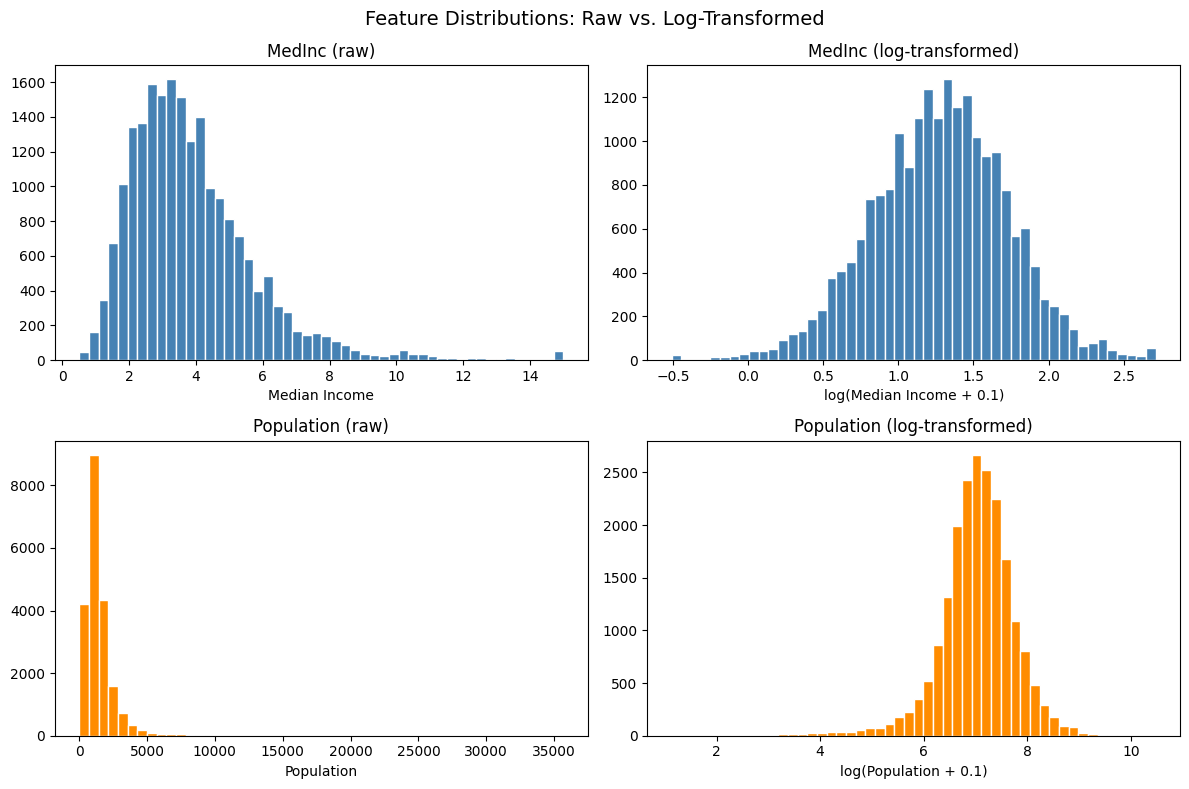

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Feature Distributions: Raw vs. Log-Transformed", fontsize=14)

raw = df[relevant_features]

axes[0, 0].hist(raw["MedInc"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("MedInc (raw)")
axes[0, 0].set_xlabel("Median Income")

axes[0, 1].hist(X["MedInc"], bins=50, color="steelblue", edgecolor="white")
axes[0, 1].set_title("MedInc (log-transformed)")
axes[0, 1].set_xlabel("log(Median Income + 0.1)")

axes[1, 0].hist(raw["Population"], bins=50, color="darkorange", edgecolor="white")
axes[1, 0].set_title("Population (raw)")
axes[1, 0].set_xlabel("Population")

axes[1, 1].hist(X["Population"], bins=50, color="darkorange", edgecolor="white")
axes[1, 1].set_title("Population (log-transformed)")
axes[1, 1].set_xlabel("log(Population + 0.1)")

plt.tight_layout()
plt.show()

## 3. Train the One-Class SVM

We convert the DataFrame to a NumPy array and fit the model.

### Hyperparameter Choices

- `kernel='rbf'` – We use the RBF kernel (see equation above) so the model can learn non-linear boundaries.
- `nu=0.03` – We allow up to **3%** of training points to be on the wrong side of the boundary (i.e., we expect roughly 3% outliers). This is also a lower bound on the fraction of support vectors.
- `gamma=0.001` – A small value gives a **smooth, broad** decision boundary, which is appropriate here since our features are on a roughly similar scale after the log transform.

You can re-run the notebook with `nu=0.10` or `gamma=0.1` and observe how the number and location of detected outliers changes.

In [ ]:
# Convert to a 2D NumPy array (required by scikit-learn)
X_array = X.to_numpy()

# Instantiate the model
svm = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.03)
print("Model:", svm)

# Fit the model on ALL the data
# (One-Class SVM is unsupervised — there is no separate train/test split required,
#  though in practice you might hold out a validation set to tune hyperparameters)
svm.fit(X_array)

# Predict: +1 = inlier, -1 = outlier
predictions = svm.predict(X_array)

n_outliers = (predictions == -1).sum()
n_inliers  = (predictions == +1).sum()
print(f"\nTotal points : {len(predictions)}")
print(f"Inliers  (+1): {n_inliers}  ({100 * n_inliers / len(predictions):.1f}%)")
print(f"Outliers (-1): {n_outliers} ({100 * n_outliers / len(predictions):.1f}%)")

Model: OneClassSVM(gamma=0.001, nu=0.03)

Total points : 20640
Inliers  (+1): 20022  (97.0%)
Outliers (-1): 618 (3.0%)


## 6. Inspect the Outliers

Let's look at some of the detected outlier rows in the **original** (untransformed) feature space to see what makes them unusual.

In [ ]:
# Get the indices of outliers
outlier_indices = np.where(predictions == -1)[0]

# Show a sample of outlier rows from the original DataFrame
print(f"Showing 10 of {len(outlier_indices)} detected outliers (original scale):")
display(df.iloc[outlier_indices[:10]][relevant_features])

Showing 10 of 618 detected outliers (original scale):


,MedInc,Population
59,2.5625,94.0
61,6.1183,86.0
73,0.4999,18.0
88,0.9722,125.0
92,0.7500,191.0
121,4.9643,98.0
283,5.9849,4985.0
570,7.6110,7427.0
576,7.2634,5781.0
700,6.5000,83.0


## 4. Visualise the Results

We plot two scatter charts side by side:
- **Left:** All data points (the original distribution)
- **Right:** Inliers in blue, detected outliers highlighted in red

Both axes show the **log-transformed** features.

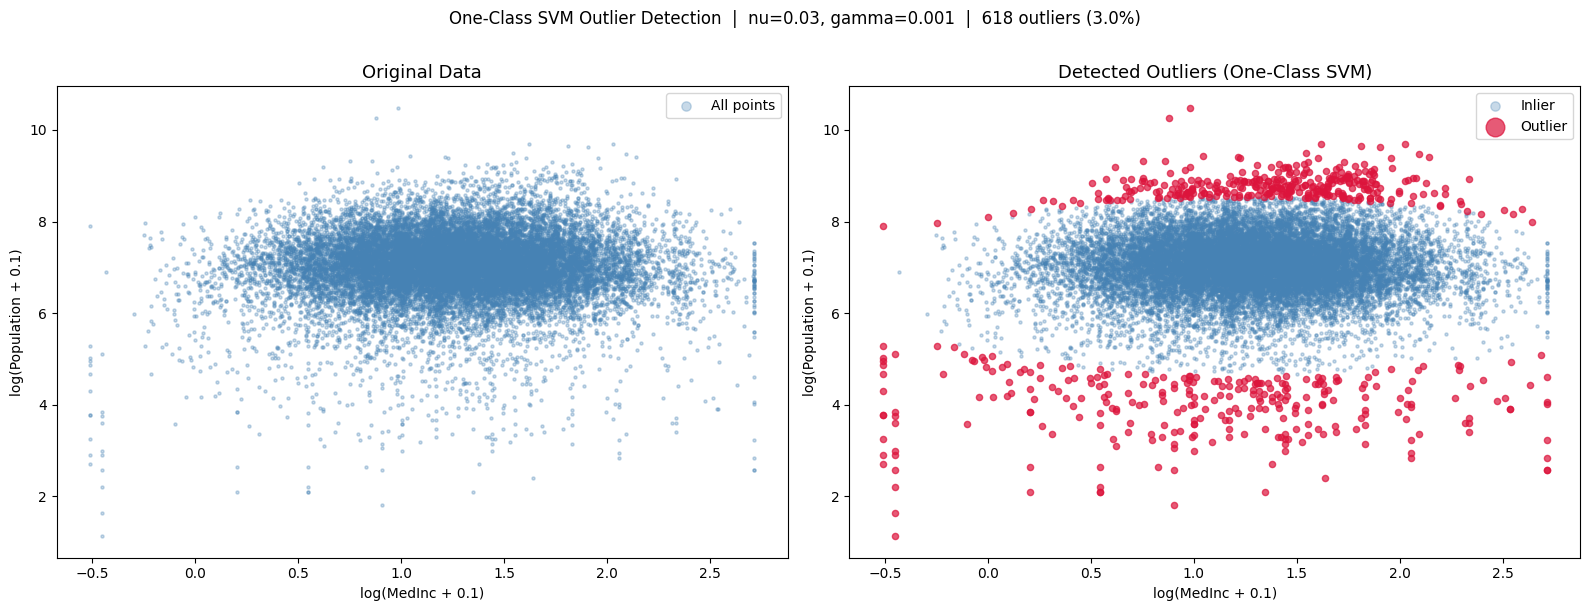

In [ ]:
# Separate inliers and outliers for plotting
inlier_mask  = predictions == +1
outlier_mask = predictions == -1

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: all data (ground truth / original distribution) ---
ax0.scatter(
    X_array[:, 0], X_array[:, 1],
    s=5, alpha=0.3, color="steelblue", label="All points"
)
ax0.set_title("Original Data", fontsize=13)
ax0.set_xlabel("log(MedInc + 0.1)")
ax0.set_ylabel("log(Population + 0.1)")
ax0.legend(markerscale=3)

# --- Right: inliers vs. outliers ---
ax1.scatter(
    X_array[inlier_mask, 0], X_array[inlier_mask, 1],
    s=5, alpha=0.3, color="steelblue", label="Inlier"
)
ax1.scatter(
    X_array[outlier_mask, 0], X_array[outlier_mask, 1],
    s=20, alpha=0.7, color="crimson", label="Outlier"
)
ax1.set_title("Detected Outliers (One-Class SVM)", fontsize=13)
ax1.set_xlabel("log(MedInc + 0.1)")
ax1.set_ylabel("log(Population + 0.1)")
ax1.legend(markerscale=3)

plt.suptitle(
    f"One-Class SVM Outlier Detection  |  nu={svm.nu}, gamma={svm.gamma}  |  "
    f"{n_outliers} outliers ({100 * n_outliers / len(predictions):.1f}%)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()